In [1]:
class PolynomialRegression:
    def __init__(self, degree=2):
        self.degree = degree
        self.coefficients_ = None
        self.intercept_ = None
        self.r2score_ = None
        self.poly_features = None
        
    def fit(self, X, y):
        self.poly_features = PolynomialFeatures(degree=self.degree, include_bias=True)
        X_poly = self.poly_features.fit_transform(X)
        # Normal equation
        self.coefficients_ = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        # Predictions and R²
        y_pred = X_poly.dot(self.coefficients_)
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred
        
    def predict(self, X):
        X_poly = self.poly_features.transform(X)
        return X_poly.dot(self.coefficients_)

Polynomial LR Coefficients: [2.18057235 0.94831275 0.4165796 ]
R² Score: 0.92


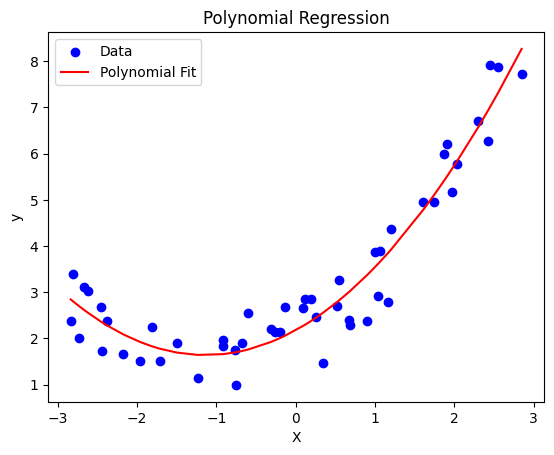

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

X_poly = np.random.rand(50,1)*6 - 3
y_poly = 0.5*X_poly**2 + X_poly + 2 + np.random.randn(50,1)*0.5
y_poly = y_poly.flatten()
pr = PolynomialRegression(degree=2)
pr.fit(X_poly, y_poly)
print(f"Polynomial LR Coefficients: {pr.coefficients_}")
print(f"R² Score: {pr.r2score_:.2f}")


plt.scatter(X_poly, y_poly, color='blue', label='Data')
plt.plot(np.sort(X_poly, axis=0), pr.y_pred_[np.argsort(X_poly, axis=0)], color='red', label='Polynomial Fit')
plt.title("Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()